In [1]:
from LIMxCMBL.init import *
from LIMxCMBL.noise import *
from scipy.signal.windows import dpss
import sys
Lambda_idx = 18#int(sys.argv[1])
nbins = 50#int(sys.argv[2])

Lambda = Lambdas[Lambda_idx]

zmin = 3.5#float(sys.argv[3])
zmax = 8.1#float(sys.argv[4])

chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))


oup_fname = '/scratch/users/delon/LIMxCMBL/eHIeHI/mpmath_comb_zmin_%.5f_zmax_%.5f_Lambda_idx_%.d_from_quad_nbins_%d.npy'%(zmin, zmax, Lambda_idx, nbins)
print(oup_fname)


chi_bin_edges = np.linspace(chimin*(1+1e-8), chimax*(1 - 1e-8), nbins + 1)
eHIeHI_binned = np.zeros((nbins,nbins), dtype=np.float64)
dchi = np.mean(np.diff(chi_bin_edges))

/scratch/users/delon/LIMxCMBL/eHIeHI/mpmath_comb_zmin_3.50000_zmax_8.10000_Lambda_idx_18_from_quad_nbins_50.npy


In [2]:
from scipy.integrate import quad, dblquad, nquad


def compute_bin_element(params):
    i, j, l1, r1, l2, r2, dchi, Lambda, chimin, chimax = params
    sigma = 1 / Lambda
    
    eIeI = 0
    if i == j:
        center = (l1 + r1) / 2
        eIeI = f_eIeI(chi=center, dchi=dchi, Lambda=Lambda)
    
    def integrand(x, xp, xb):
        _f_cross = lambda chi, chip : (1/chi**2  * 1 / np.sqrt(2*np.pi*sigma**2)
                                      * np.exp(- (chi - chip)**2 / 2 / sigma**2)
                                      + 1/chip**2  * 1 / np.sqrt(2*np.pi*sigma**2) 
                                      * np.exp(- (chip - chi)**2 / 2 / sigma**2))
        _f_eLOeLO = lambda chi, chip, chib : (1 / (2 * np.pi * sigma**2) / chib**2
                                                    * np.exp(- (chi  - chib)**2 / 2 / sigma**2)
                                                    * np.exp(- (chip - chib)**2 / 2 / sigma**2))

        return _f_eLOeLO(chi = x, chip = xp, chib = xb) - _f_cross(chi = x, chip = xp) / (chimax_sample * 10 - 10)
    
    options1 = {'limit':100000, 'epsabs':0.0, 'epsrel':1e-3, 
                'points':(chimin, l1, (l1+r1)/2, r1, chimax)}
    options2 = {'limit':100000, 'epsabs':0.0, 'epsrel':1e-3, 
                'points':(chimin, l2, (l2+r2)/2, r2, chimax)}
    options3 = {'limit':100000, 'epsabs':0.0, 'epsrel':1e-3, 
                'points':(chimin, l1, l2, (l1+r1)/2, (l2+r2)/2, r1, r2, chimax)}


    LOLO_m_cross, _ = nquad(integrand, [[l1, r1],[l2, r2],[10, chimax_sample * 10]],
                   opts=[options1,options2, options3])
    LOLO_m_cross = LOLO_m_cross / dchi**2
    
    return (i, j, eIeI + LOLO_m_cross)

In [3]:
params_list = []
for i, (l1, r1) in enumerate(zip(chi_bin_edges[:-1], chi_bin_edges[1:])):
    for j, (l2, r2) in enumerate(zip(chi_bin_edges[:-1], chi_bin_edges[1:])):
        params = (i, j, l1, r1, l2, r2, dchi, Lambda, chimin, chimax)
        params_list.append(params)

In [4]:
with Pool(processes=32) as pool:
        results = list(tqdm(
            pool.imap(compute_bin_element, params_list),
            total=len(params_list)
        ))


100%|██████████| 2500/2500 [06:26<00:00,  6.46it/s]


In [5]:
import pickle

with open(oup_fname+'_results.pkl', 'wb') as f:
    print(oup_fname+'_results.pkl')
    pickle.dump(results, f)
print('outputted')


for i, j, value in results:
    eHIeHI_binned[i, j] = np.real(value)

np.save(oup_fname, eHIeHI_binned)
print('binned eHIeHI outputed to', oup_fname)

In [6]:
import matplotlib.pyplot as plt

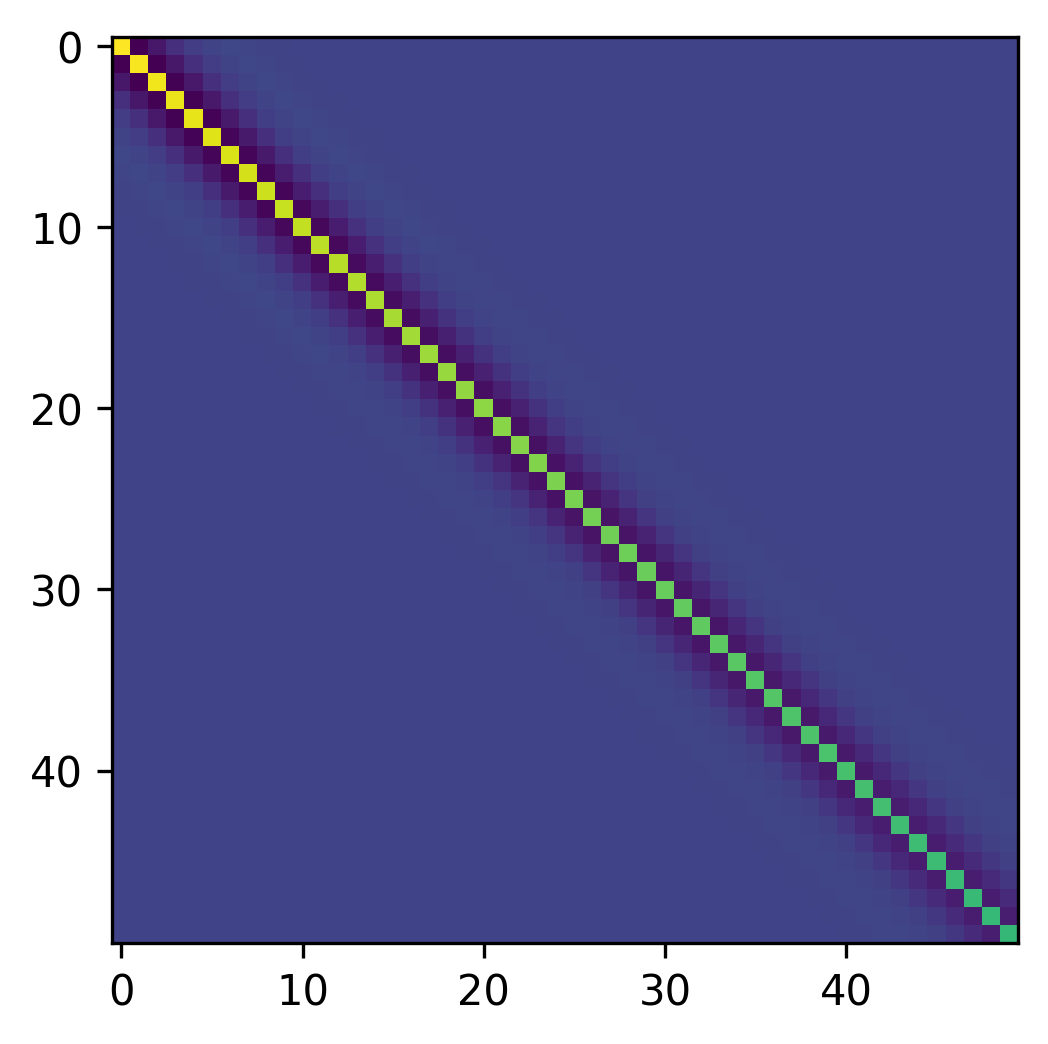

In [7]:
plt.figure(dpi=300)
plt.imshow(eHIeHI_binned)

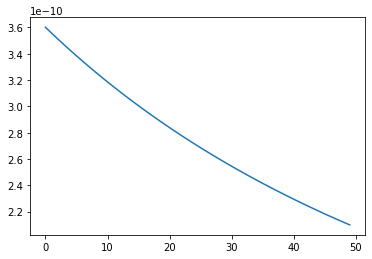

In [8]:
plt.plot(np.diag(eHIeHI_binned))

In [9]:
import numpy as np

def covariance_to_correlation(covariance_matrix):
    variances = np.diag(covariance_matrix)
    if np.any(variances < 0):
        raise ValueError("negative variances")
    std_devs = np.sqrt(variances)
    
    inv_std_devs = 1 / std_devs
    D_inv = np.diag(inv_std_devs)
    correlation_matrix = D_inv @ covariance_matrix @ D_inv
    np.fill_diagonal(correlation_matrix, 1.0)
    
    return correlation_matrix

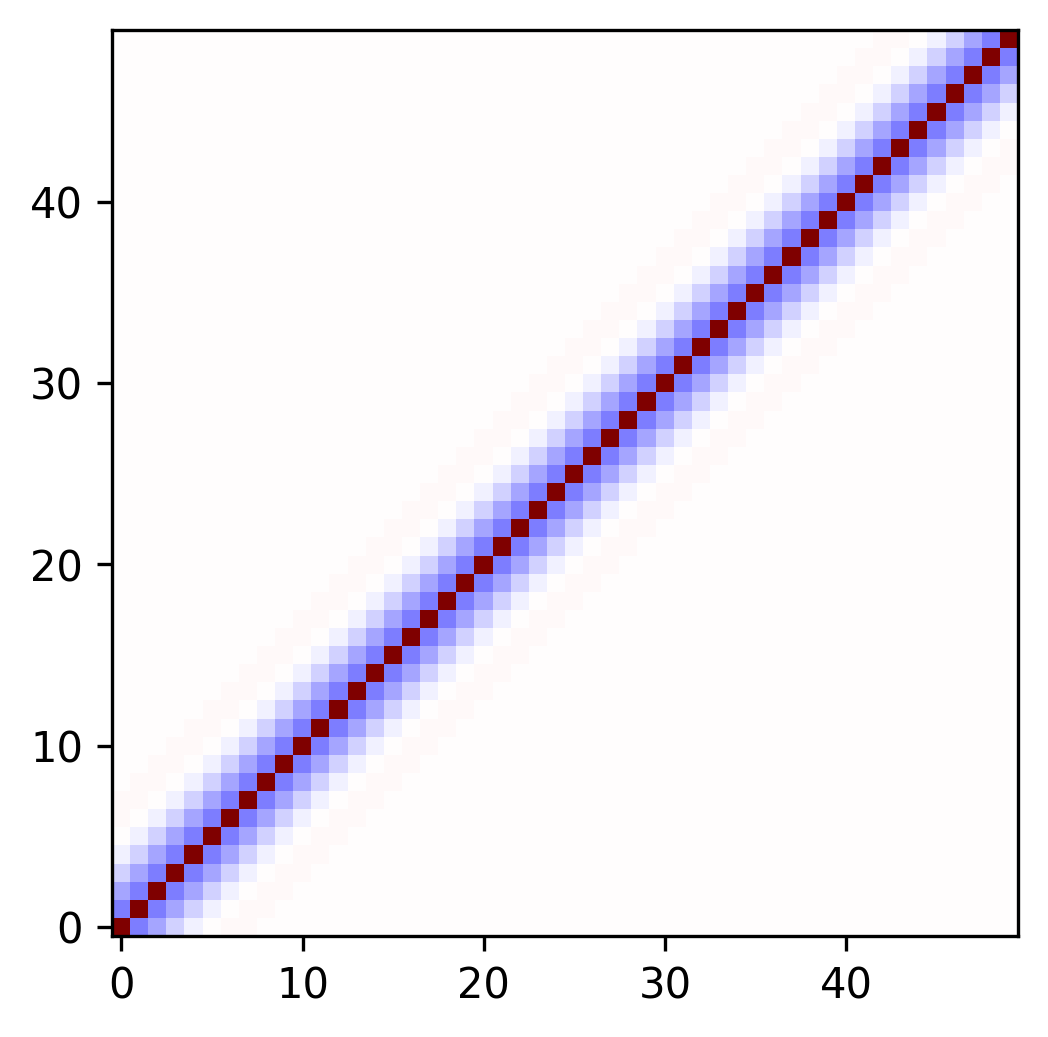

In [10]:
plt.figure(dpi = 300)
plt.imshow(covariance_to_correlation(eHIeHI_binned), 
           vmin = -1,
           vmax = 1,
           cmap = 'seismic',
             interpolation = 'none',
             origin = 'lower')